## EIS Parameter Estimation with CMA-ES in PyBOP

In this notebook, we demonstrate an example of parameter estimation for a single-particle model using the Covariance Matrix Adaptation Evolution Strategy (CMA-ES). CMA-ES is an evolutionary algorithm for difficult non-linear, non-convex optimisation problems.

### Setting up the Environment

Before we begin, we need to ensure that we have all the necessary tools. We will install PyBOP from its development branch and upgrade some dependencies:

In [1]:
%pip install --upgrade pip ipywidgets
%pip install pybop -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Importing Libraries

With the environment set up, we can now import PyBOP alongside other libraries we will need:

In [2]:
import numpy as np
from plotly import graph_objects as go

import pybop

### Generate Synthetic Data

To demonstrate parameter estimation, we first need some data. We will generate synthetic data using the PyBOP forward model, which requires defining a parameter set and the model itself.

#### Defining Parameters and Model

We start by creating an example parameter set and then instantiate the single-particle model (SPM):

In [3]:
parameter_set = pybop.ParameterSet.pybamm("Chen2020")
model = pybop.lithium_ion.SPM(parameter_set=parameter_set)

### Simulating Forward Model

We can then simulate the model using the `predict` method, with a default constant current to generate voltage data.

In [4]:
t_eval = np.arange(0, 900, 2)
values = model.predict(t_eval=t_eval)

### Adding Noise to Voltage Data

To make the parameter estimation more realistic, we add Gaussian noise to the data.

In [5]:
sigma = 0.001
corrupt_values = values["Voltage [V]"].data + np.random.normal(0, sigma, len(t_eval))

## Identify the Parameters

We will now set up the parameter estimation process by defining the datasets for optimisation and selecting the model parameters we wish to estimate.

### Creating Optimisation Dataset

The dataset for optimisation is composed of time, current, and the noisy voltage data:

In [6]:
dataset = pybop.Dataset(
    {
        "Time [s]": np.arange(0, 5, 1),
        "Current function [A]": np.ones(5) * 0.1,
        # "Voltage [V]": corrupt_values,
        "Impedence": np.ones(5)
        * 0.001,  # [(-0.01738600525868403+0.09453297477642258j), (-0.00018417554898900756+0.00985070656754582j), (-1.8428710788297802e-06+0.000985496810305584j), (-1.842882243913148e-08+9.855010749698755e-05j), (-1.8428823555649024e-10+9.855011176168316e-06j)]
    }
)

### Defining Parameters to Estimate

We select the parameters for estimation and set up their prior distributions and bounds:

In [7]:
parameters = [
    pybop.Parameter(
        "Negative electrode active material volume fraction",
        prior=pybop.Gaussian(0.7, 0.05),
        bounds=[0.6, 0.9],
    ),
    pybop.Parameter(
        "Positive electrode active material volume fraction",
        prior=pybop.Gaussian(0.58, 0.05),
        bounds=[0.5, 0.8],
    ),
]

### Setting up the Optimisation Problem

With the datasets and parameters defined, we can set up the optimisation problem, its cost function, and the optimiser.

In [8]:
signal = ["Impedence"]
problem = pybop.FittingProblem(model, parameters, dataset, signal=signal, eis=True)
cost = pybop.SumSquaredError(problem)
optim = pybop.Optimisation(cost, optimiser=pybop.CMAES)
optim.set_max_iterations(100)

In [9]:
zs = problem.evaluate([0.7, 0.58])

In [10]:
fig = go.Figure(
    go.Scatter(
        x=[zs["Impedence"][i].real for i in range(len(zs["Impedence"]))],
        y=[-zs["Impedence"][i].imag for i in range(len(zs["Impedence"]))],
        mode="markers",
    ),
    layout=go.Layout(xaxis_title="Real", yaxis_title="Imaginary", title="Impedence"),
)
fig.show()

In [11]:
[zs["Impedence"][i].real for i in range(len(zs["Impedence"]))]

[1.842882243913148e-08,
 1.5230431929640136e-08,
 1.2797793599816416e-08,
 1.0904628934670025e-08,
 9.40246070995974e-09,
 8.190588029193116e-09,
 7.198759033742905e-09,
 6.376755424458927e-09,
 5.687908400877136e-09,
 5.104937189617238e-09,
 4.607205821244521e-09,
 4.178871499136285e-09,
 3.8076081268411895e-09,
 3.4837095186641034e-09,
 3.199448501932142e-09,
 2.948611741836749e-09,
 2.7261573077061118e-09,
 2.5279593158055577e-09,
 2.3506152325351406e-09,
 2.191298862404904e-09,
 2.0476470490684837e-09,
 1.9176715348148294e-09,
 1.7996897907022157e-09,
 1.6922702904834232e-09,
 1.5941888814331142e-09,
 1.5043937530499621e-09,
 1.421977120363095e-09,
 1.3461521902517164e-09,
 1.2762343136305257e-09,
 1.2116254761853179e-09,
 1.1518014685274843e-09,
 1.0963012195024522e-09,
 1.0447178856571988e-09,
 9.966913740363483e-10,
 9.519020407372454e-10,
 9.100653585794254e-10,
 8.709273872225192e-10,
 8.342609106325212e-10,
 7.998621318566632e-10,
 7.675478350668495e-10,
 7.37152940872606e-10

### Running the Optimisation

We proceed to run the CMA-ES optimisation algorithm to estimate the parameters:

In [12]:
x, final_cost = optim.run()

### Viewing the Estimated Parameters

After the optimisation, we can examine the estimated parameter values:

In [13]:
x  # This will output the estimated parameters

array([0.71484828, 0.54766709])

## Plotting and Visualisation

PyBOP provides various plotting utilities to visualise the results of the optimisation.

### Comparing System Response

We can quickly plot the system's response using the estimated parameters compared to the target:

In [14]:
pybop.quick_plot(problem, parameter_values=x, title="Optimised Comparison");

ValueError: operands could not be broadcast together with shapes (990,) (5,) 

### Convergence and Parameter Trajectories

To assess the optimisation process, we can plot the convergence of the cost function and the trajectories of the parameters:

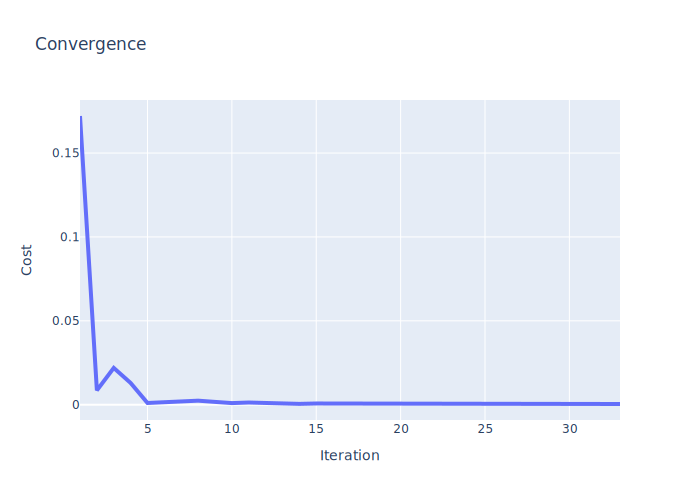

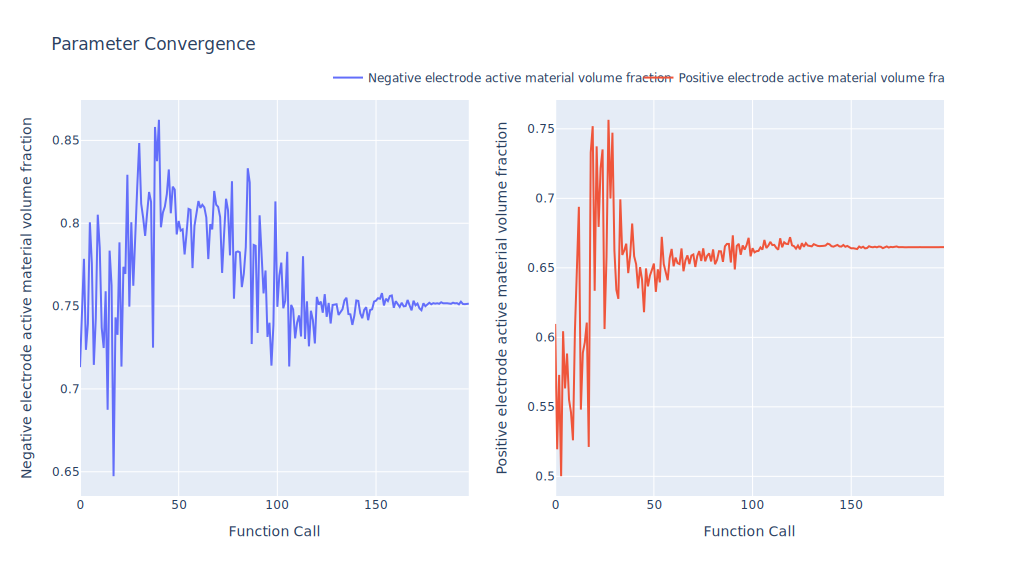

In [ ]:
pybop.plot_convergence(optim)
pybop.plot_parameters(optim);

### Cost Landscape

Finally, we can visualise the cost landscape and the path taken by the optimiser:

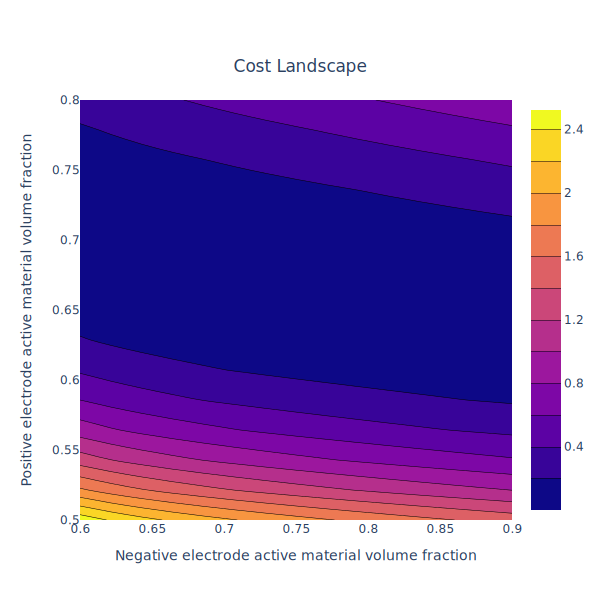

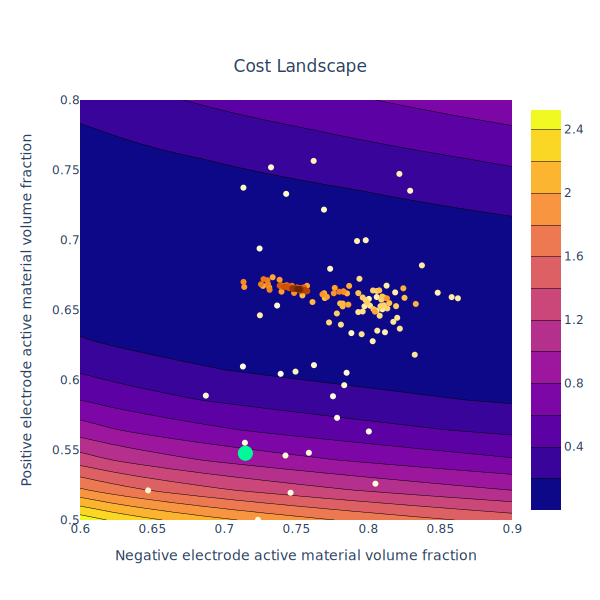

In [ ]:
# Plot the cost landscape
pybop.plot2d(cost, steps=15)
# Plot the cost landscape with optimisation path and updated bounds
bounds = np.array([[0.6, 0.9], [0.5, 0.8]])
pybop.plot2d(optim, bounds=bounds, steps=15);

### Conclusion

This notebook illustrates how to perform parameter estimation using CMA-ES in PyBOP, providing insights into the optimisation process through various visualisations.